We have a dataset tvmarketing.csv which contains 2 columns
- One showing the amount of money spent on the TV advertisement in hundred-thousands.
- Second showing the amount of product sales due to that advertisement in hundred-thousands.
We we train a model to predict the number of sales for a given amount of money spent in advertisement.

In [1]:
# import dependencies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<Axes: xlabel='TV', ylabel='Sales'>

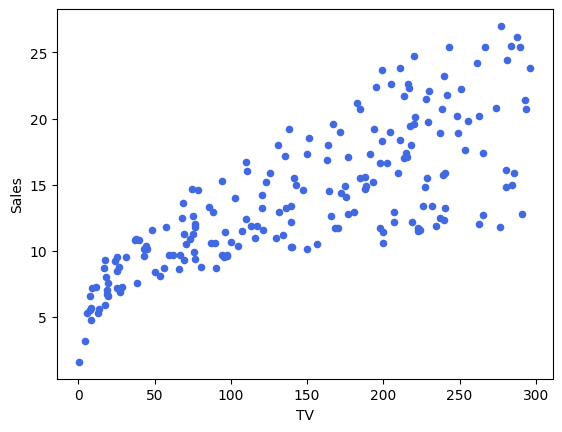

In [2]:
# Load the data
df = pd.read_csv('./Datasets/tvmarketing.csv')
X = df["TV"]
Y = df["Sales"] 
df.plot(x="TV",y="Sales",kind="scatter",color="royalblue")

Original arrays X and Y have different units. To make gradient descent algorithm efficient, you need to bring them to the same units. A common approach to it is called normalization: substract the mean value of the array from each of the elements in the array and divide them by standard deviation (a statistical measure of the amount of dispersion of a set of values).There are many Normalization techniques :
- Min-Max Scaling
- Z-score Normalization
- Mean Normalization
- Max Absolute Scaling
...etc

The technique we are using here is Z-score Normalization. Normalization does not change the relation between the datas it simply scales down the data into some smaller range.

Normalization is not compulsory - gradient descent would work without it. But due to different units of X and Y, the cost function will be much steeper. Then you would need to take a significantly smaller learning rate  𝛼 and the algorithm will require thousands of iterations to converge instead of a few dozens. Normalization helps to increase the efficiency of the gradient descent algorithm.

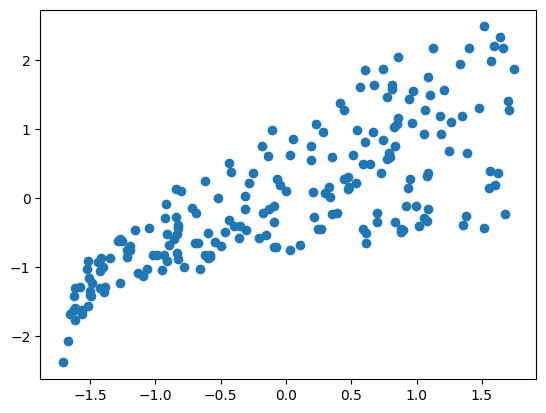

In [3]:
# Normalization
X_norm = (X - np.mean(X))/np.std(X)
Y_norm = (Y - np.mean(Y))/np.std(Y)
plt.scatter(X_norm,Y_norm)

Our predicted datas will form a line,
$$\hat{Y}=WX + b$$
Here,
$\hat{Y}$ = Predicted sales
$W$ = Slope/weight
$X$ = price of advertisement
$b$ = inctercept/bias
Here error will be calculated with
$$\text{Loss Function, }L=\frac{1}{2}(\hat{y}^i-y^i)^2$$
for each of the training data. Divison by 2 is just taken for scaling purpose.
Hence the overall error is given by taking the average of all errors
$$E(m,b)=\frac{1}{2n}\sum_{i=1}^n(\hat{y}^i-y^i)^2=\frac{1}{2n}\sum_{i=1}^n(mx^i+b-y^i)^2$$
This is called Cost Function. Our goal is to minimise this function hence we have to use Gradient Descent. Here our unknown variables are m and b so we have to take partial derivative of the cost function w.r.t m and b :
$$	\begin{align}
	\frac{\partial E}{\partial m}&=\frac{1}{n}\sum_{i=1}^n(mx^i+b-y^i)x^i, \\
	\frac{\partial E}{\partial b}&=\frac{1}{n}\sum_{i=1}^n(mx^i+b-y^i),
	\end{align}$$
and update the parameters of m and b iteratively as :
$$	\begin{align}
	m&=m-\alpha\frac{\partial E}{\partial m}, \\
	b&=b-\alpha\frac{\partial E}{\partial b}
	\end{align}$$
Here $\alpha$ is learning rate

In [4]:
# define cost function
def E(m, b, X, Y):
    return 1/(2*len(Y))*np.sum((m*X + b - Y)**2)


In [5]:
# partial differentiation w.r.t m and b
def dEdm(m, b, X, Y):
    res = 1/len(X)*np.dot(m*X + b - Y, X) 
    return res
    

def dEdb(m, b, X, Y):
    res = 1/len(X)*np.sum(m*X + b - Y)
    return res


In [6]:
# Gradient descent to update m and b
def gradient_descent(dEdm, dEdb, m, b, X, Y, learning_rate = 0.001, num_iterations = 1000, print_cost=False):
    for iteration in range(num_iterations):
        m_new = m-learning_rate*dEdm(m,b,X,Y)
        b_new = b-learning_rate*dEdb(m,b,X,Y)
        m = m_new
        b = b_new
        if print_cost:
            print (f"Cost after iteration {iteration}: {E(m, b, X, Y)}")
        
    return m, b

In [8]:
# taking random stating m and b, and run for 30 iteration on each iteration we calculate error, once error become stagnant we reached optimal m and b value.
m_initial = 0; b_initial = 0; num_iterations = 30; learning_rate = 1.2
m_gd, b_gd = gradient_descent(dEdm, dEdb, m_initial, b_initial, 
                              X_norm, Y_norm, learning_rate, num_iterations, print_cost=True)

print(f"Gradient descent result: m_min, b_min = {m_gd}, {b_gd}") 

Cost after iteration 0: 0.2062999755919659
Cost after iteration 1: 0.19455197461564455
Cost after iteration 2: 0.19408205457659172
Cost after iteration 3: 0.19406325777502959
Cost after iteration 4: 0.1940625059029671
Cost after iteration 5: 0.1940624758280846
Cost after iteration 6: 0.1940624746250893
Cost after iteration 7: 0.19406247457696948
Cost after iteration 8: 0.19406247457504472
Cost after iteration 9: 0.19406247457496772
Cost after iteration 10: 0.19406247457496462
Cost after iteration 11: 0.19406247457496453
Cost after iteration 12: 0.19406247457496453
Cost after iteration 13: 0.19406247457496448
Cost after iteration 14: 0.19406247457496448
Cost after iteration 15: 0.19406247457496448
Cost after iteration 16: 0.19406247457496448
Cost after iteration 17: 0.19406247457496448
Cost after iteration 18: 0.19406247457496448
Cost after iteration 19: 0.19406247457496448
Cost after iteration 20: 0.19406247457496448
Cost after iteration 21: 0.19406247457496448
Cost after iteration 22:

Remember, that the initial datasets were normalized. To make the predictions, you need to normalize X_pred array, calculate Y_pred with the linear regression coefficients m_gd, b_gd and then denormalize the result (perform the reverse process of normalization):

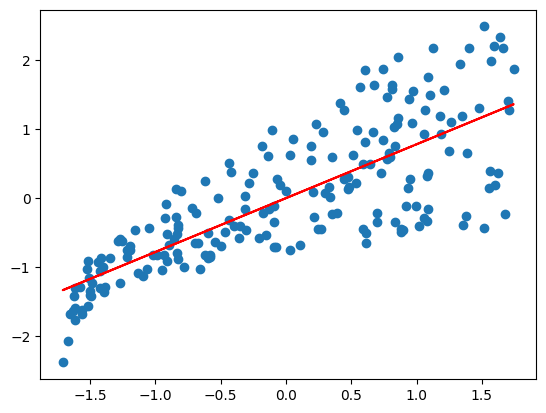

In [12]:
plt.scatter(X_norm,Y_norm)
Y_pred_with_gd = m_gd*X_norm + b_gd
plt.plot(X_norm,Y_pred_with_gd,c="red")

In [13]:
X_pred = np.array([50, 120, 280])
# Use the same mean and standard deviation of the original training array X
X_pred_norm = (X_pred - np.mean(X))/np.std(X)
Y_pred_gd_norm = m_gd * X_pred_norm + b_gd
# Use the same mean and standard deviation of the original training array Y
Y_pred_gd = Y_pred_gd_norm * np.std(Y) + np.mean(Y)

print(f"TV marketing expenses:\n{X_pred}")
print(f"Predictions of sales using Gradient Descent:\n{Y_pred_gd}")

TV marketing expenses:
[ 50 120 280]
Predictions of sales using Gradient Descent:
[ 9.40942557 12.7369904  20.34285287]
